In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
import pandas as pd
import networkx as nx
import random
import matplotlib.pyplot as plt
# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
from IPython.core.display import HTML
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version built with PyTorch: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU name: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("PyTorch was not built with CUDA support or CUDA is not configured correctly.")


PyTorch version: 2.2.2
CUDA available: False
PyTorch was not built with CUDA support or CUDA is not configured correctly.


In [3]:
import warnings
warnings.filterwarnings("ignore", message=".*PossibleUserWarning.*")
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=".*to enable TensorBoard support.*")

import os, sys
sys.stderr = open(os.devnull, 'w')

In [4]:
import sys
from pathlib import Path

_cwd = Path().resolve()
_candidates = (_cwd, _cwd.parent)
for _root in _candidates:
    if (_root / 'node_diffusion').exists():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break
else:
    raise ModuleNotFoundError("Could not locate 'node_diffusion' package; adjust sys.path.")

del _cwd, _candidates, _root


# Code

In [5]:
def offset_neg_graphs(graphs, targets, offset=10):
    out_graphs = []
    for graph, target in zip(graphs, targets):
        if target == 0:
            for u in graph.nodes():
                graph.nodes[u]['label'] += offset
        out_graphs.append(graph.copy())
    return out_graphs, targets

In [6]:
from coco_grape.visualizer.display import draw_graphs
def plot_sample(sampled_graphs, sampled_targets, haystack=None, n_lines=3, n_graphs_per_line=12):
    pos_graphs = [sampled_graph for sampled_graph, sampled_target in zip(sampled_graphs, sampled_targets) if sampled_target==1][:n_graphs_per_line*n_lines]
    neg_graphs = [sampled_graph for sampled_graph, sampled_target in zip(sampled_graphs, sampled_targets) if sampled_target!=1][:n_graphs_per_line*n_lines]
    gs = pos_graphs + neg_graphs
    if haystack is not None:
        ts = list(compute_is_valid(pos_graphs, haystack)) + list(compute_is_valid(neg_graphs, haystack))
        draw_graphs(gs, ts, n_graphs_per_line=n_graphs_per_line)
    else:
        draw_graphs(gs, n_graphs_per_line=n_graphs_per_line)

In [7]:
def select_pos_neg(sampled_graphs, sampled_targets, n_lines=3, n_graphs_per_line=12):
    pos_graphs = [sampled_graph for sampled_graph, sampled_target in zip(sampled_graphs, sampled_targets) if sampled_target==1][:n_graphs_per_line*n_lines]
    neg_graphs = [sampled_graph for sampled_graph, sampled_target in zip(sampled_graphs, sampled_targets) if sampled_target!=1][:n_graphs_per_line*n_lines]
    return pos_graphs, neg_graphs

In [8]:
import math
import hashlib
import matplotlib.pyplot as plt
import networkx as nx
from coco_grape.visualizer.mol_display import draw_molecules
    
def plot_networkx_graphs(graphs, cmap='tab20', light=0.4, size=4, n_cols=None, show_label=True, color_offset=200, mode='not_molecule'):
    """
    Plot a list of NetworkX graphs in a grid.
    
    Each node is drawn with a color determined by its 'label' attribute.
    The color is chosen persistently (so nodes with the same label always get the same color)
    and then lightened by the given factor.
    
    Parameters:
        graphs (list): List of networkx.Graph objects.
        cmap: Matplotlib colormap or a string name for a colormap. Defaults to 'Set2'.
        light (float): A value in [0, 1] used to lighten colors 
                       (0 leaves the color unchanged, 1 turns it white). Defaults to 0.3.
        size (int, optional): Size (in inches) for each individual square plot (default: 4).
        n_cols (int, optional): Number of columns in the grid. If None, defaults to the number of graphs.
        show_label (bool, optional): If True, displays the node's label on the plot.
    """
    if mode == 'molecule':
        draw_molecules(graphs)
        return
        
    # If cmap is given as a string, get the corresponding matplotlib colormap
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
        
    n_graphs = len(graphs)
    if n_cols is None:
        n_cols = n_graphs
    n_rows = math.ceil(n_graphs / n_cols)
    
    # Create subplots with no border on the plots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(size * n_cols, size * n_rows))
    
    # Ensure axes is a flat list (handle case with one or multiple rows/cols)
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1 or n_cols == 1:
        axes = list(axes.flatten())
    else:
        axes = axes.flatten()
    
    def get_color_for_label(label):
        """
        Given a label (string), returns a persistent color based on a hash.
        The base color is obtained from the cmap and then lightened.
        """
        label_str = str(label)
        # Use MD5 for a deterministic hash (consistent across invocations)
        hash_val = hashlib.md5(label_str.encode('utf-8')).hexdigest()
        numeric_hash = int(hash_val, 16)+color_offset
        # Normalize to [0, 1] using mod 1000 for a quick spread
        normalized = (numeric_hash % 1000) / 999.0
        base_color = cmap(normalized)  # returns an RGBA tuple
        
        # Lighten the color: interpolate between base_color and white (1,1,1)
        lightened = tuple((1 - light) * base_color[i] + light for i in range(3))
        # Preserve alpha if available
        if len(base_color) == 4:
            lightened += (base_color[3],)
        return lightened

    # Loop over each graph and plot it on its corresponding axis
    for i, G in enumerate(graphs):
        ax = axes[i]
        ax.axis('off')  # Remove borders/ticks
        
        # Compute layout using the Kamada–Kawai algorithm
        pos = nx.kamada_kawai_layout(G)
        
        # Get colors for nodes using the node's 'label' attribute
        node_colors = []
        labels = {}
        for n in G.nodes():
            label = G.nodes[n].get('label', '')
            node_colors.append(get_color_for_label(label))
            labels[n] = str(label)
            
        # Draw edges and nodes with a black border for each node
        nx.draw_networkx_edges(G, pos, width=2, ax=ax)
        nx.draw_networkx_nodes(
            G, pos, ax=ax, node_color=node_colors, edgecolors='black', linewidths=2,
        )
        
        # Optionally, draw labels if show_label is True
        if show_label:
            nx.draw_networkx_labels(G, pos, labels=labels, ax=ax)
    
    # Hide any unused axes if the grid is larger than the number of graphs
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()


In [9]:
def show_samples(n_samples, graphs, targets, decompositional_encoder_decoder):
    neg_graphs = [graph for graph, target in zip(graphs, targets) if target==0]
    pos_graphs = [graph for graph, target in zip(graphs, targets) if target!=0]

    print("Positive Graphs:")
    plot_networkx_graphs(pos_graphs[:n_samples], n_cols=n_samples)
    sampled_graphs = decompositional_encoder_decoder.sample_from(pos_graphs, n_samples)
    print("Sampled Positive Graphs:")
    plot_networkx_graphs(sampled_graphs, n_cols=len(sampled_graphs))

    print("Negative Graphs:")   
    plot_networkx_graphs(neg_graphs[:n_samples], n_cols=n_samples)
    sampled_graphs = decompositional_encoder_decoder.sample_from(neg_graphs, n_samples)
    print("Sampled Negative Graphs:")
    plot_networkx_graphs(sampled_graphs, n_cols=len(sampled_graphs))

---

# Data

In [10]:
DATASET_TYPE = 'MOLECULAR'

In [11]:
DATASET_TYPE = 'ARTIFICIAL'

In [12]:
def build_dataset(dataset_size=50):
    if DATASET_TYPE == 'ARTIFICIAL':
        from coco_grape.utils.artificial_graph_constructor import ArtificialGraphDatasetConstructor
        graph_types = ['path', 'tree', 'cycle', 'degree', 'regular', 'dense']
        alphabet_size = 3
        size = 5
        graphs, targets = ArtificialGraphDatasetConstructor(
            graph_generator_target_type_pos='cycle', 
            graph_generator_context_type_pos='cycle', 
            graph_generator_target_type_neg='tree',
            graph_generator_context_type_neg='tree', 
            target_size_pos=size, 
            context_size_pos=size, 
            n_link_edges_pos=1,
            alphabet_size_pos=alphabet_size,
            target_size_neg=size, 
            context_size_neg=size, 
            n_link_edges_neg=1,
            alphabet_size_neg=alphabet_size).sample(dataset_size//2)

        graphs, targets = offset_neg_graphs(graphs, targets, offset=alphabet_size)

        from coco_grape.utils.canonical_order import canonicalise
        #graphs = [canonicalise(graph) for graph in graphs]

        #graph_array = np.empty(len(graphs), dtype=object)
        #for i, graph in enumerate(graphs): graph_array[i] = graph
        #graphs = graph_array
        #haystack = np.unique(make_graph_signature_mtx(graphs),axis=0)
        #print('dataset has %d different templates'%len(haystack))
        print('#graphs:%d'%(len(graphs)))
        
        n_graphs_per_line = 8
        pos_graphs, neg_graphs = select_pos_neg(graphs, targets, n_lines=1, n_graphs_per_line=n_graphs_per_line)
        #plot_sample(graphs, targets, haystack)
        plot_networkx_graphs(pos_graphs, n_cols=n_graphs_per_line)
        plot_networkx_graphs(neg_graphs, n_cols=n_graphs_per_line)
        

    elif DATASET_TYPE == 'MOLECULAR':
        from coco_grape.visualizer.mol_display import draw_molecules
        
        from coco_grape.data_loader.mol.mol_loader import PubChemLoader
        assay_ids = ['2631','624249','651741','588350','463230','492952','743219','492992','463213','651610', '630']
        from coco_grape.data_loader.loader import SupervisedDataSetLoader
        assay_id=assay_ids[-4]
        assay_id = '651610'
        def pubchem_loader(): return PubChemLoader().load(assay_id)
        original_graphs, original_targets = SupervisedDataSetLoader(pubchem_loader, size=dataset_size, use_equalized=False).load()
        original_graphs = np.array(original_graphs, dtype=object)
        original_targets = np.array(original_targets)
        print('#graphs:%d   class split:%s'%(len(original_graphs), np.bincount(original_targets)))


        max_node_size = 19
        print('...filter by size <= %d'%max_node_size)
        idxs = [idx for idx, graph in enumerate(original_graphs) if nx.number_of_nodes(graph)<=max_node_size]
        print('#graphs:%d '%(len(idxs)))
        graphs = original_graphs[idxs].tolist()
        targets = original_targets[idxs]

        from coco_grape.visualizer.mol_display import draw_molecules
        draw_molecules(graphs[:7*2])
    return graphs, targets

---

# Experiment

In [13]:
nbits = 11
verbose = True

---

In [14]:
from coco_grape.module.quotientgraph.display import display, display_mappings, display_decomposition_graph, decomposition_to_graph
from coco_grape.module.quotientgraph.vectorize import QuotientGraphTransformer, QuotientGraphNodeTransformer
from coco_grape.module.quotientgraph.operator import *

df0_list = [compose(combination(distance=(d,d)), node(), prepend_label(label=d)) for d in range(2,10)]
df0 = add(*df0_list)
df1 = add(df0, cycle(), tree(), path(number_of_edges=(1,3)), neighborhood(radius=(0,2)))
df2 = compose(df1, unlabel())
df = add(df1,df2)

node_graph_vectorizer = QuotientGraphNodeTransformer(decomposition_function=df, nbits=nbits)
graph_vectorizer = QuotientGraphTransformer(decomposition_function=df, nbits=nbits)

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from node_diffusion.low_rank_mlp import LowRankMLP

latent_embedding_dimension=128
number_of_transformer_layers=4
transformer_attention_head_count=4
total_steps = 100
learning_rate = 1e-4
maximum_epochs = 500
batch_size=16
lambda_degree_importance = 1
lambda_node_exist_importance = 1
degree_temperature = 1
lambda_locality_importance = 1

eqm_sigma = 0.2
sampling_step_size = 0.05
langevin_noise_scale = 0.0

from node_diffusion.eqm_conditional_node_generator import EqMConditionalNodeGenerator
conditional_node_generator_model = EqMConditionalNodeGenerator(
    latent_embedding_dimension=latent_embedding_dimension,
    number_of_transformer_layers=number_of_transformer_layers,
    transformer_attention_head_count=transformer_attention_head_count,
    transformer_dropout=.2,
    learning_rate=learning_rate,
    maximum_epochs=maximum_epochs,
    batch_size=batch_size,
    total_steps=total_steps,
    verbose=verbose,
    lambda_degree_importance=lambda_degree_importance,
    lambda_node_exist_importance=lambda_node_exist_importance,
    degree_temperature=degree_temperature,
    lambda_locality_importance=lambda_locality_importance,
    use_guidance=False,
    use_locality_supervision=True,
    eqm_sigma=eqm_sigma,
    sampling_step_size=sampling_step_size,
    langevin_noise_scale=langevin_noise_scale,
)

from node_diffusion.decompositional_encoder_decoder import ConditionalNodeGeneratorModel
conditioning_to_node_embeddings_generator = ConditionalNodeGeneratorModel(
    conditional_node_generator=conditional_node_generator_model, 
    verbose=verbose)

USE_RANDOM_FOREST_CLASSIFIER = False

if USE_RANDOM_FOREST_CLASSIFIER:
    node_label_classifier = RandomForestClassifier(n_estimators=300, n_jobs=-1)
    edge_label_classifier = RandomForestClassifier(n_estimators=300, n_jobs=-1)
    adjacency_matrix_classifier = RandomForestClassifier(n_estimators=300, n_jobs=-1)
else:

    max_epochs = 200
    from node_diffusion.low_rank_mlp import LowRankMLP
    hidden_dim = 32
    node_label_classifier = LowRankMLP(
        hidden_layers=2,
        hidden_dim=hidden_dim,
        thin_size=hidden_dim//3,
        dropout=0.5,
        negative_slope=0.01,
        lr=1e-4,
        max_epochs=max_epochs,
        batch_size=batch_size,
        lr_patience=5,
        task='classification',
        verbose=verbose
    )

    hidden_dim = 16
    edge_label_classifier = LowRankMLP(
        hidden_layers=2,
        hidden_dim=hidden_dim,
        thin_size=hidden_dim//4,
        dropout=0.5,
        negative_slope=0.01,
        lr=1e-4,
        max_epochs=max_epochs,
        batch_size=batch_size,
        lr_patience=5,
        task='classification',
        verbose=verbose
    )

    hidden_dim = 32
    adjacency_matrix_classifier = LowRankMLP(
        hidden_layers=2,
        hidden_dim=hidden_dim,
        thin_size=int(hidden_dim/1.75),
        dropout=0.3,
        negative_slope=0.01,
        lr=1e-4,
        max_epochs=max_epochs,
        batch_size=batch_size,
        lr_patience=5,
        task='classification',
        verbose=verbose
    )

from node_diffusion.decompositional_encoder_decoder import DecompositionalNodeEncoderDecoder
"""
negative_sample_factor           : Ratio for sampling negative locality pairs per positive.
existence_threshold        : Threshold to consider a node existent.
num_augmentation_iterations: Number of augmentation noise iterations.
augmentation_noise         : Maximum noise amplitude for augmentation.
enforce_connectivity       : Whether to enforce a single connected component.
degree_slack_penalty       : Weight applied to slack variables for degree deviations.
warm_start_mst             : Whether to warm start solver using maximum spanning tree.
"""
node_embeddings_to_graph_generator = DecompositionalNodeEncoderDecoder(
    adjacency_matrix_classifier=adjacency_matrix_classifier, 
    node_label_classifier=node_label_classifier,
    edge_label_classifier=edge_label_classifier,
    verbose=verbose,
    negative_sample_factor=2,
    num_augmentation_iterations=1,
    augmentation_noise=1e-1,
    enforce_connectivity=True,
    warm_start_mst=True)

from node_diffusion.decompositional_encoder_decoder import DecompositionalEncoderDecoder
decompositional_encoder_decoder = DecompositionalEncoderDecoder(
    graph_vectorizer=graph_vectorizer,
    node_graph_vectorizer=node_graph_vectorizer, 
    conditioning_to_node_embeddings_generator=conditioning_to_node_embeddings_generator,
    node_embeddings_to_graph_generator=node_embeddings_to_graph_generator,
    use_locality_supervision=True,
    locality_sample_fraction=.3,
    locality_horizon=2,
    verbose=verbose)



---

#graphs:487


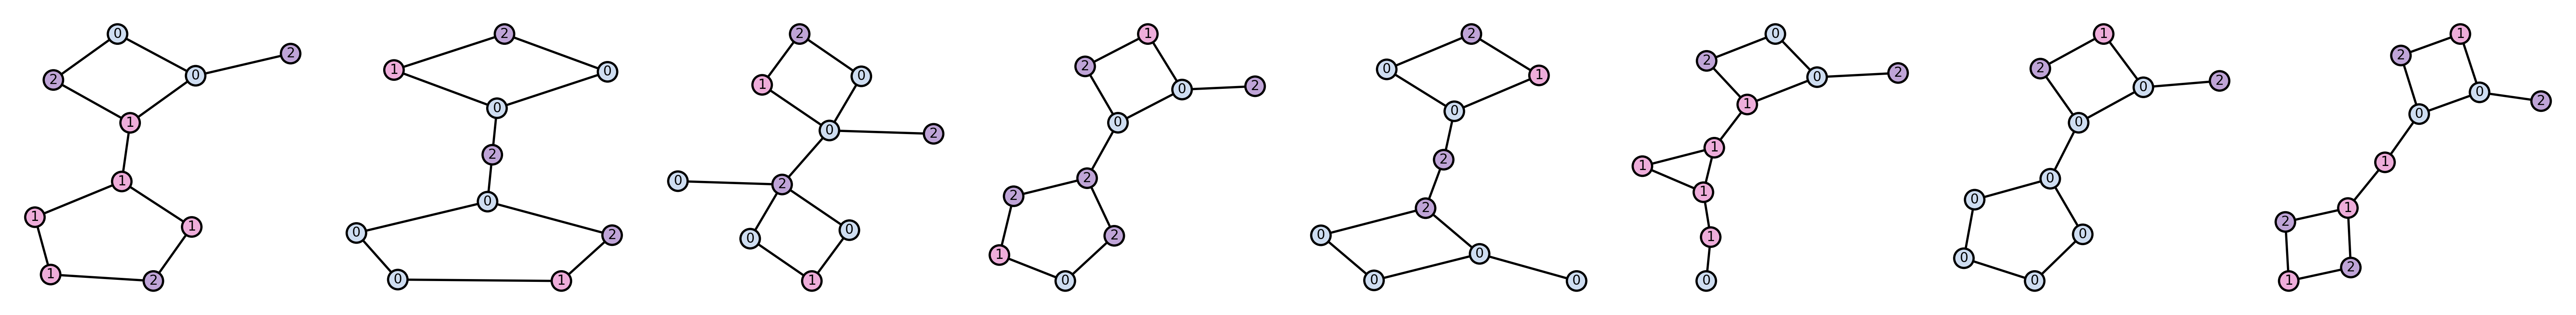

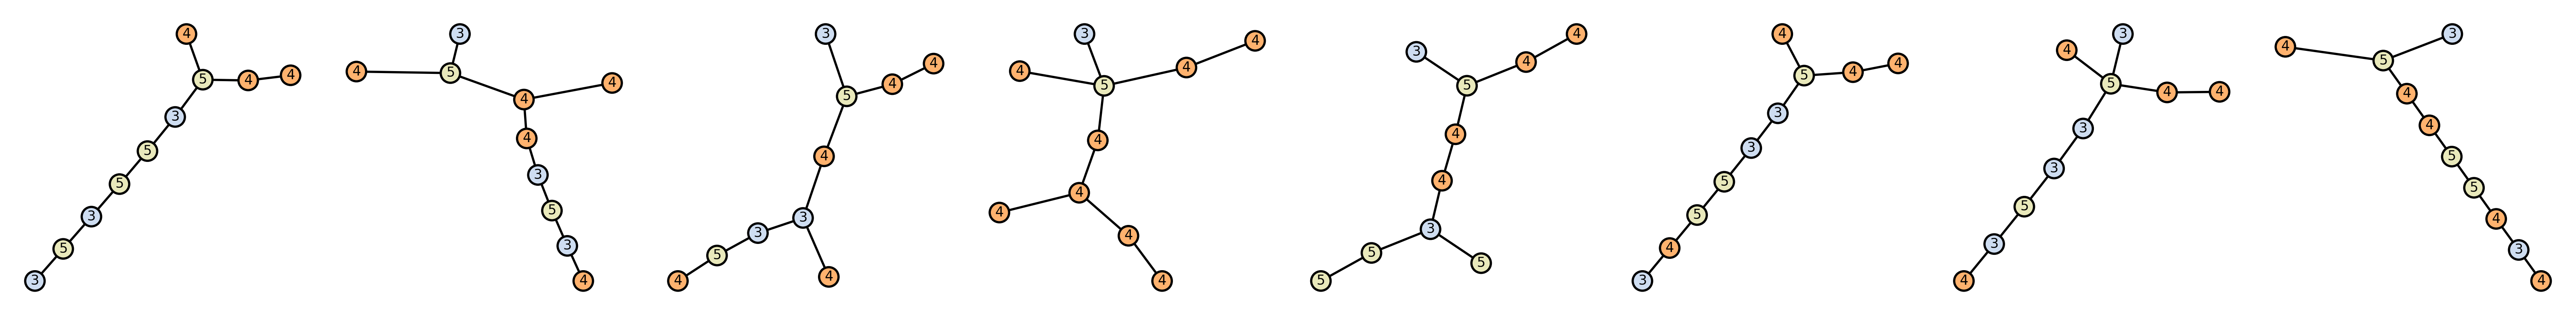

train_graphs:477   test_graphs:10


In [16]:
graphs, targets = build_dataset(dataset_size=500)

from sklearn.model_selection import train_test_split
# Assuming `graphs` and `targets` are lists or numpy arrays
train_graphs, test_graphs, train_targets, test_targets = train_test_split(
    graphs, targets, test_size=10, random_state=42  # Adjust test_size as needed
)
print(f'train_graphs:{len(train_graphs)}   test_graphs:{len(test_graphs)}')

In [ ]:
%%time
decompositional_encoder_decoder.fit(train_graphs, train_conditioning_to_node_embeddings_generator=True, train_node_embeddings_to_graph_generator=True)


Fitting model on 477 graphs
Node encoding 477 graphs


In [ ]:
show_samples(n_samples=7, graphs=graphs, targets=targets, decompositional_encoder_decoder=decompositional_encoder_decoder)

---